In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import json

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

from src.utils.seed import set_seed
from src.models.deepconvnet import DeepConvNet
from src.losses.icrr_loss import icrr_loss
from src.evaluation.ess import compute_ess

In [3]:
SEED = 42
set_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
DATA_DIR = PROJECT_ROOT / "datasets"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

ABLATION_TABLE_DIR = TABLES_DIR / "projection_icrr_ablation"
MODEL_COMP_FIG_DIR = FIGURES_DIR / "model_comparisons"
EMBED_FIG_DIR = FIGURES_DIR / "embedding_geometry"

for p in [ABLATION_TABLE_DIR, MODEL_COMP_FIG_DIR, EMBED_FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "bnci_dataset" / "processed" / "preprocessed_BNCI.npz"   

In [5]:
d = np.load(DATA_PATH, allow_pickle=True)
X = d["X"].astype(np.float32)
y = d["y"].astype(int)

print("BNCI Shape:", X.shape)
print("Classes:", np.unique(y))

BNCI Shape: (640, 25, 561)
Classes: [0 1 2 3]


In [6]:
class EEGDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])

In [7]:
def run_kfold_icrr(lambda_icrr=0.1, epochs=50):

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    all_emb_ce = []
    all_emb_icrr = []
    all_labels = []

    fold_ess_ce = []
    fold_ess_icrr = []

    ce_loss_fn = nn.CrossEntropyLoss()

    for fold, (tr, te) in enumerate(skf.split(X, y), 1):

        ds_tr = EEGDataset(X[tr], y[tr])
        ds_te = EEGDataset(X[te], y[te])

        loader_tr = DataLoader(ds_tr, batch_size=32, shuffle=True)
        loader_te = DataLoader(ds_te, batch_size=64, shuffle=False)

        # CE model
        model_ce = DeepConvNet(25, 561, classes=4).to(device)
        opt_ce = optim.Adam(model_ce.parameters(), lr=1e-3)

        for ep in range(epochs):
            model_ce.train()
            for xb, yb in loader_tr:
                xb, yb = xb.to(device), yb.to(device)
                opt_ce.zero_grad()
                logits = model_ce(xb)
                loss = ce_loss_fn(logits, yb)
                loss.backward()
                opt_ce.step()

        model_ce.eval()
        emb_ce_fold = []
        labels_fold = []

        with torch.no_grad():
            for xb, yb in loader_te:
                xb = xb.to(device)
                logits, z = model_ce(xb, return_embedding=True)
                emb_ce_fold.append(z.cpu().numpy())
                labels_fold.append(yb.numpy())

        emb_ce_fold = np.concatenate(emb_ce_fold)
        labels_fold = np.concatenate(labels_fold)

        ess_ce = compute_ess(emb_ce_fold, labels_fold)
        fold_ess_ce.append(ess_ce)

        # CE + ICRR
        model_icrr = DeepConvNet(25, 561, classes=4).to(device)
        opt_icrr = optim.Adam(model_icrr.parameters(), lr=1e-3)

        for ep in range(epochs):
            model_icrr.train()
            for xb, yb in loader_tr:
                xb, yb = xb.to(device), yb.to(device)
                opt_icrr.zero_grad()
                logits, z = model_icrr(xb, return_embedding=True)
                loss = ce_loss_fn(logits, yb) + lambda_icrr * icrr_loss(z, yb)
                loss.backward()
                opt_icrr.step()

        model_icrr.eval()
        emb_icrr_fold = []

        with torch.no_grad():
            for xb, yb in loader_te:
                xb = xb.to(device)
                logits, z = model_icrr(xb, return_embedding=True)
                emb_icrr_fold.append(z.cpu().numpy())

        emb_icrr_fold = np.concatenate(emb_icrr_fold)

        ess_icrr = compute_ess(emb_icrr_fold, labels_fold)
        fold_ess_icrr.append(ess_icrr)

        all_emb_ce.append(emb_ce_fold)
        all_emb_icrr.append(emb_icrr_fold)
        all_labels.append(labels_fold)

    global_emb_ce = np.concatenate(all_emb_ce)
    global_emb_icrr = np.concatenate(all_emb_icrr)
    global_labels = np.concatenate(all_labels)

    return (
        global_emb_ce,
        global_emb_icrr,
        global_labels,
        fold_ess_ce,
        fold_ess_icrr
    )

In [8]:
(
    emb_ce_global,
    emb_icrr_global,
    labels_global,
    fold_ess_ce,
    fold_ess_icrr
) = run_kfold_icrr(lambda_icrr=0.1, epochs=50)

In [9]:
global_ess_ce = compute_ess(emb_ce_global, labels_global)
global_ess_icrr = compute_ess(emb_icrr_global, labels_global)

results_dict = {
    "ESS_CE_mean_fold": float(np.mean(fold_ess_ce)),
    "ESS_ICRR_mean_fold": float(np.mean(fold_ess_icrr)),
    "ESS_CE_global": float(global_ess_ce),
    "ESS_ICRR_global": float(global_ess_icrr)
}

with open(ABLATION_TABLE_DIR / "compactness_summary.json", "w") as f:
    json.dump(results_dict, f, indent=4)

In [10]:
combined_embeddings = np.concatenate([emb_ce_global, emb_icrr_global])

reducer = umap.UMAP(
    n_neighbors=50,
    min_dist=0.01,
    metric="euclidean",
    random_state=42
)

reducer.fit(combined_embeddings)

umap_ce = reducer.transform(emb_ce_global)
umap_icrr = reducer.transform(emb_icrr_global)

c:\Users\Amrita\Desktop\VS_code\eeg_representation_geometry\eegvenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


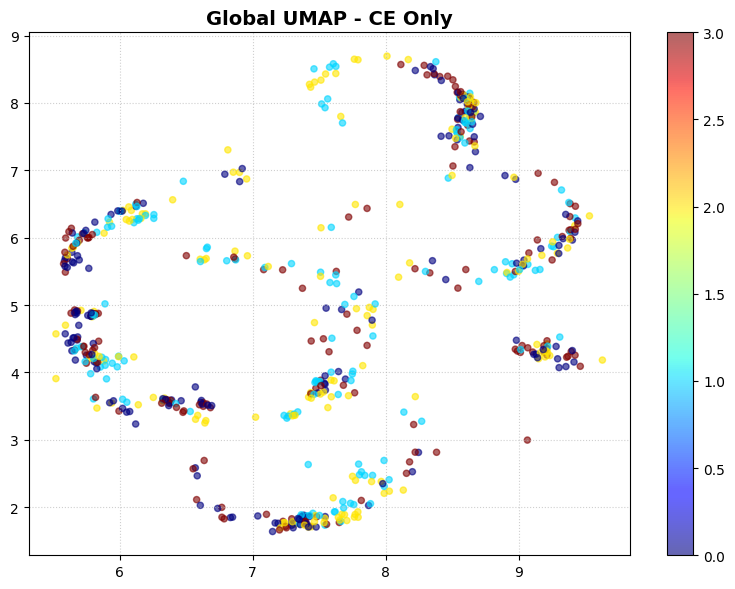

In [11]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    umap_ce[:,0],
    umap_ce[:,1],
    c=labels_global,
    cmap="jet",
    s=20,
    alpha=0.6
)

plt.title("Global UMAP - CE Only", fontsize=14, fontweight="bold")
plt.colorbar(scatter)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

plt.savefig(MODEL_COMP_FIG_DIR / "umap_backbone_ce.png", dpi=300, bbox_inches="tight")
plt.show()

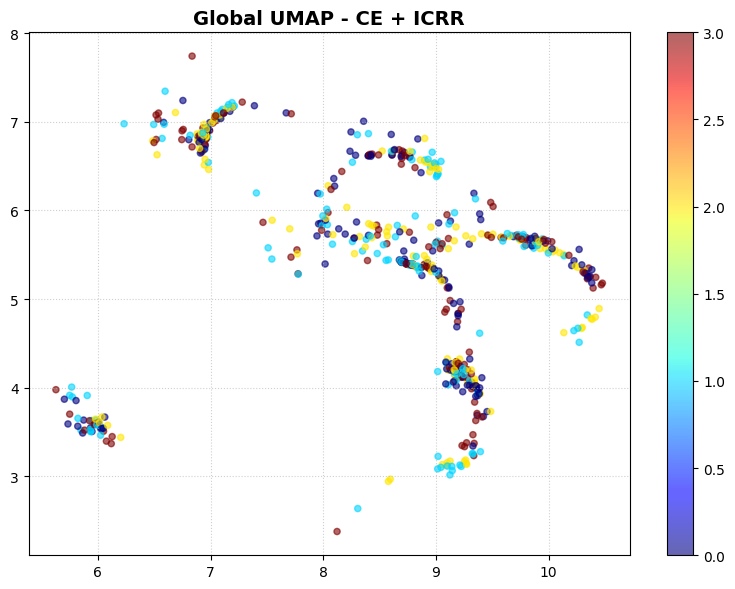

In [12]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    umap_icrr[:,0],
    umap_icrr[:,1],
    c=labels_global,
    cmap="jet",
    s=20,
    alpha=0.6
)

plt.title("Global UMAP - CE + ICRR", fontsize=14, fontweight="bold")
plt.colorbar(scatter)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

plt.savefig(MODEL_COMP_FIG_DIR / "UMAP_Backbone_ICRR.png", dpi=300, bbox_inches="tight")
plt.show()

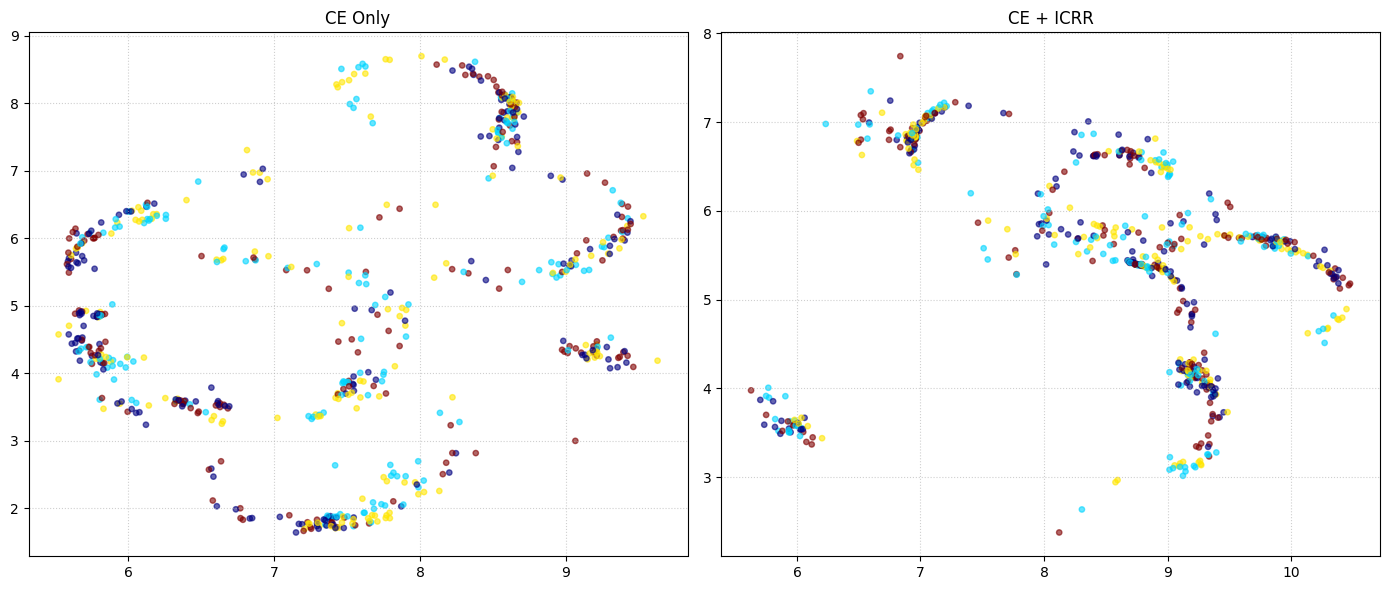

In [13]:
fig, axes = plt.subplots(1,2, figsize=(14,6))

axes[0].scatter(
    umap_ce[:,0], umap_ce[:,1],
    c=labels_global,
    cmap="jet", s=15, alpha=0.6
)
axes[0].set_title("CE Only")

axes[1].scatter(
    umap_icrr[:,0], umap_icrr[:,1],
    c=labels_global,
    cmap="jet", s=15, alpha=0.6
)
axes[1].set_title("CE + ICRR")

for ax in axes:
    ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig(MODEL_COMP_FIG_DIR / "UMAP_Backbone_CE_vs_ICRR.png", dpi=300, bbox_inches="tight")
plt.show()

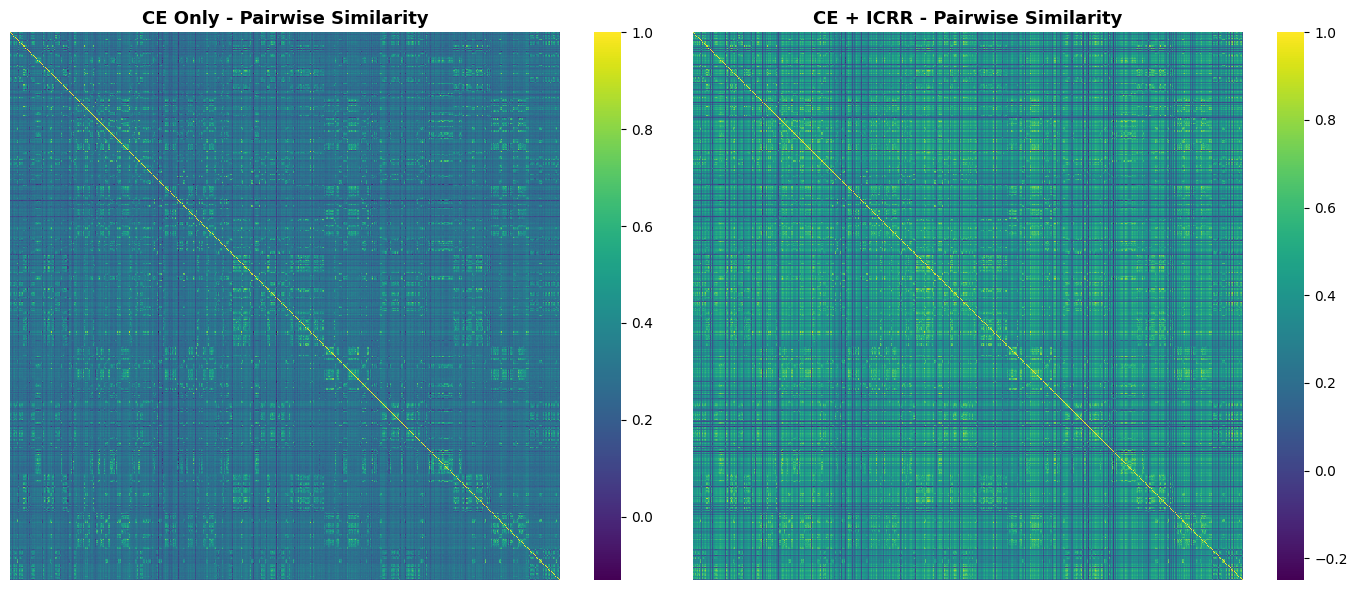

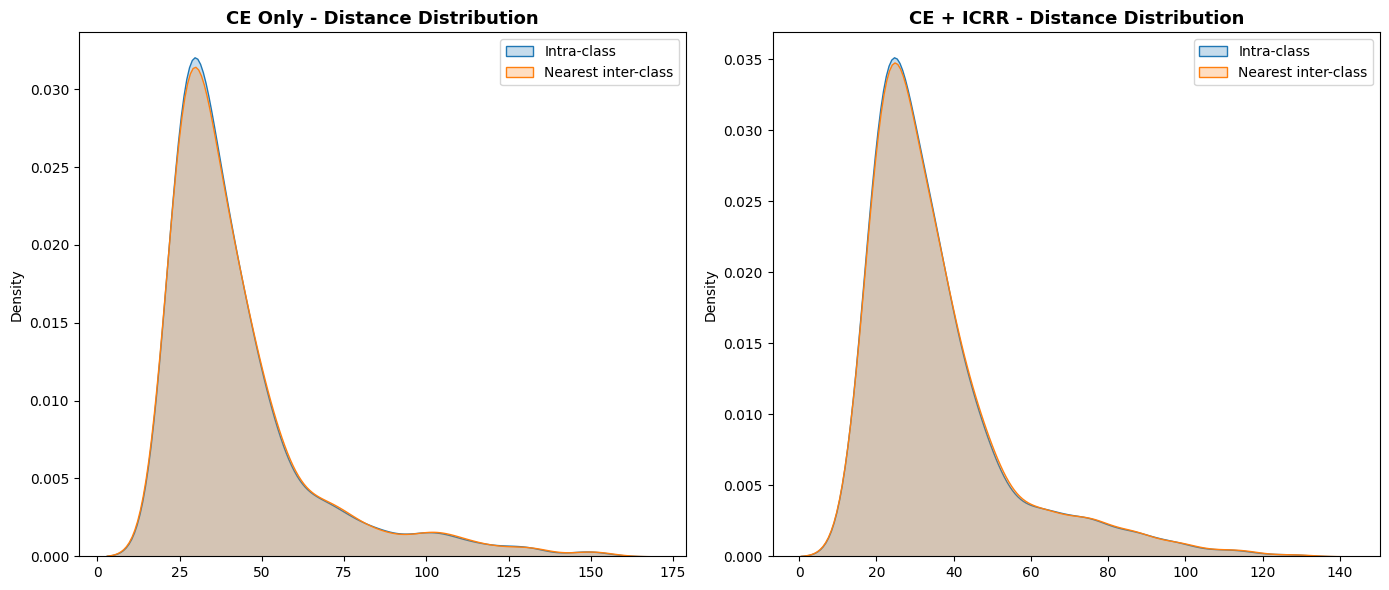

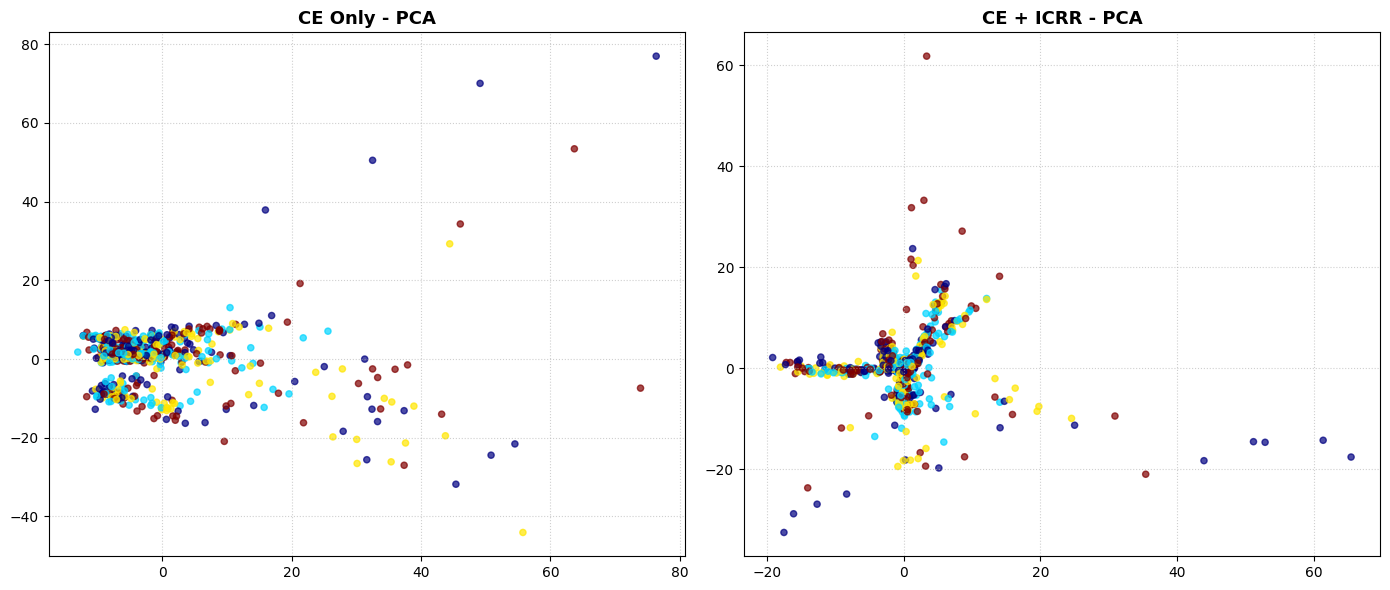

c:\Users\Amrita\Desktop\VS_code\eeg_representation_geometry\eegvenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


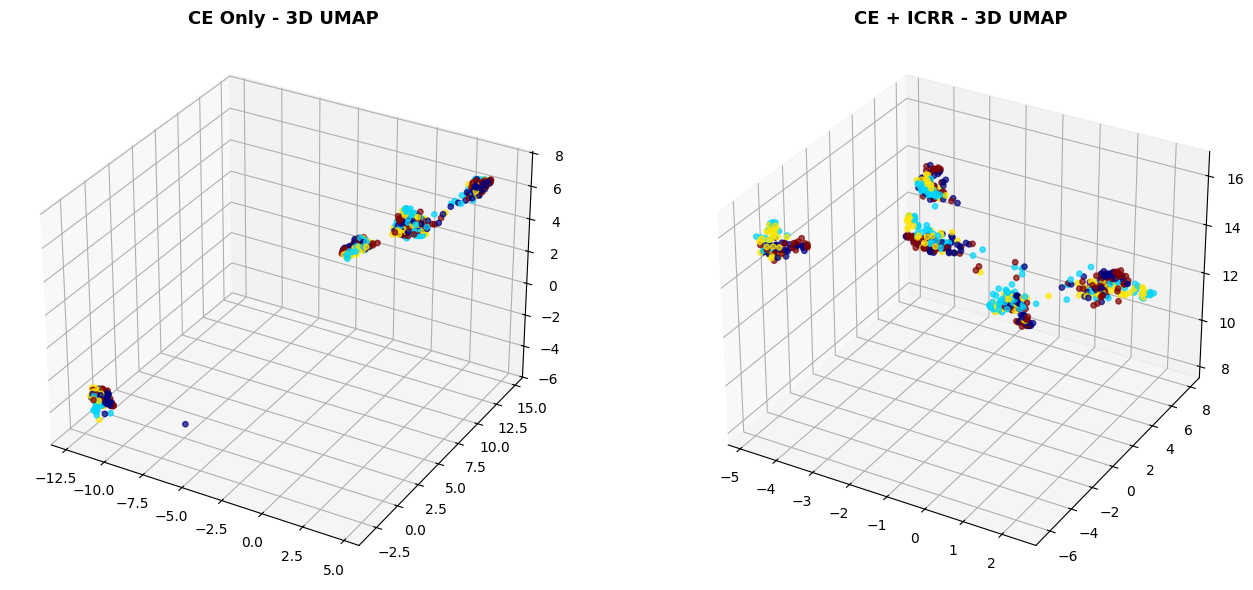

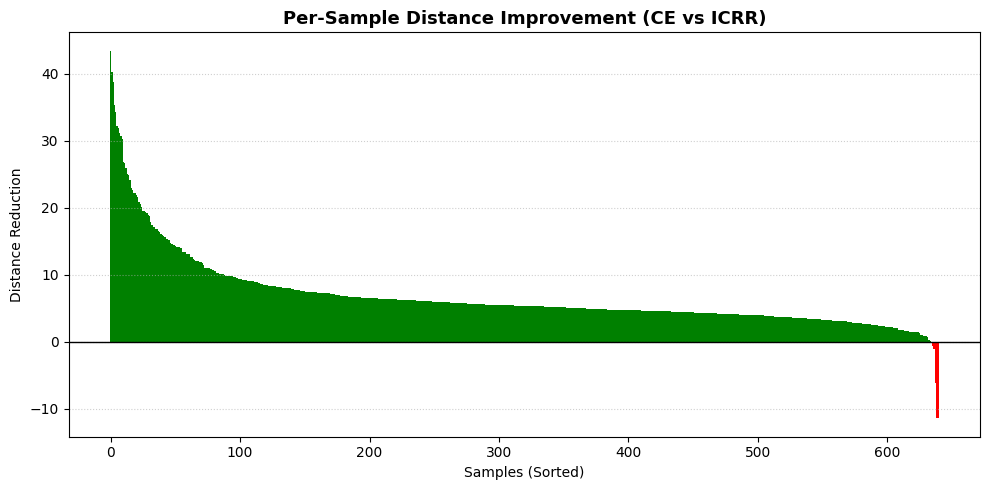

In [14]:
# Pairwise Cosine Similarity Heatmap

sort_idx = np.argsort(labels_global)
labels_sorted = labels_global[sort_idx]
emb_ce_sorted = emb_ce_global[sort_idx]
emb_icrr_sorted = emb_icrr_global[sort_idx]

sim_ce = cosine_similarity(emb_ce_sorted)
sim_icrr = cosine_similarity(emb_icrr_sorted)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(sim_ce, cmap='viridis', ax=axes[0], cbar=True,
            xticklabels=False, yticklabels=False)
axes[0].set_title("CE Only - Pairwise Similarity", fontsize=13, fontweight="bold")

sns.heatmap(sim_icrr, cmap='viridis', ax=axes[1], cbar=True,
            xticklabels=False, yticklabels=False)
axes[1].set_title("CE + ICRR - Pairwise Similarity", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(EMBED_FIG_DIR / "Global_Similarity_Heatmap.png",
            dpi=300, bbox_inches="tight")
plt.show()



# Distance Distribution (Intra vs Inter)

def get_distances(embeddings, labels):
    intra_dists = []
    inter_dists = []
    classes = np.unique(labels)
    centroids = {c: embeddings[labels == c].mean(axis=0) for c in classes}

    for i, emb in enumerate(embeddings):
        true_c = labels[i]
        intra_dists.append(np.linalg.norm(emb - centroids[true_c]))
        other_dists = [
            np.linalg.norm(emb - centroids[c])
            for c in classes if c != true_c
        ]
        inter_dists.append(np.min(other_dists))

    return np.array(intra_dists), np.array(inter_dists)

intra_ce, inter_ce = get_distances(emb_ce_global, labels_global)
intra_icrr, inter_icrr = get_distances(emb_icrr_global, labels_global)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.kdeplot(intra_ce, fill=True, ax=axes[0], label="Intra-class")
sns.kdeplot(inter_ce, fill=True, ax=axes[0], label="Nearest inter-class")
axes[0].set_title("CE Only - Distance Distribution", fontsize=13, fontweight="bold")
axes[0].legend()

sns.kdeplot(intra_icrr, fill=True, ax=axes[1], label="Intra-class")
sns.kdeplot(inter_icrr, fill=True, ax=axes[1], label="Nearest inter-class")
axes[1].set_title("CE + ICRR - Distance Distribution", fontsize=13, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig(EMBED_FIG_DIR / "Global_Distance_KDE.png",
            dpi=300, bbox_inches="tight")
plt.show()



# PCA Projection

pca = PCA(n_components=2)

pca_ce = pca.fit_transform(emb_ce_global)
pca_icrr = pca.fit_transform(emb_icrr_global)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(pca_ce[:, 0], pca_ce[:, 1],
                c=labels_global, cmap='jet', s=20, alpha=0.7)
axes[0].set_title("CE Only - PCA", fontsize=13, fontweight="bold")
axes[0].grid(True, linestyle=":", alpha=0.6)

axes[1].scatter(pca_icrr[:, 0], pca_icrr[:, 1],
                c=labels_global, cmap='jet', s=20, alpha=0.7)
axes[1].set_title("CE + ICRR - PCA", fontsize=13, fontweight="bold")
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig(EMBED_FIG_DIR / "Global_PCA_Projection.png",
            dpi=300, bbox_inches="tight")
plt.show()



# 3D UMAP

reducer_3d = umap.UMAP(n_components=3, random_state=42)

umap3d_ce = reducer_3d.fit_transform(emb_ce_global)
umap3d_icrr = reducer_3d.fit_transform(emb_icrr_global)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(umap3d_ce[:, 0], umap3d_ce[:, 1], umap3d_ce[:, 2],
            c=labels_global, cmap='jet', s=15, alpha=0.7)
ax1.set_title("CE Only - 3D UMAP", fontsize=13, fontweight="bold")

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(umap3d_icrr[:, 0], umap3d_icrr[:, 1], umap3d_icrr[:, 2],
            c=labels_global, cmap='jet', s=15, alpha=0.7)
ax2.set_title("CE + ICRR - 3D UMAP", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(EMBED_FIG_DIR / "Global_3D_UMAP.png",
            dpi=300, bbox_inches="tight")
plt.show()



# ESS Delta Waterfall

def get_intra_distances(embeddings, labels):
    classes = np.unique(labels)
    centroids = {c: embeddings[labels == c].mean(axis=0) for c in classes}
    return np.array([
        np.linalg.norm(embeddings[i] - centroids[labels[i]])
        for i in range(len(labels))
    ])

dist_ce = get_intra_distances(emb_ce_global, labels_global)
dist_icrr = get_intra_distances(emb_icrr_global, labels_global)

improvement = np.sort(dist_ce - dist_icrr)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if x > 0 else 'red' for x in improvement]

ax.bar(range(len(improvement)), improvement,
       color=colors, width=1.0)
ax.axhline(0, color='black', linewidth=1)

ax.set_title("Per-Sample Distance Improvement (CE vs ICRR)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Distance Reduction")
ax.set_xlabel("Samples (Sorted)")
ax.grid(True, axis='y', linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig(EMBED_FIG_DIR / "ESS_Delta_Waterfall.png",
            dpi=300, bbox_inches="tight")
plt.show()